#IPL DATA

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("hello")

hello


In [28]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("hello")

hello


In [30]:
matches=pd.read_csv("matches.csv")
deliveries=pd.read_csv("deliveries.csv")


#basic 

In [31]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [32]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [33]:
matches.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [34]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [35]:
matches.duplicated().sum()

np.int64(0)

In [36]:
print(matches.isnull().sum()[matches.isnull().sum() > 0])

city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64


In [37]:
matches["city"]=matches["city"].fillna("unknown")

In [38]:
matches["player_of_match"]=matches["player_of_match"].fillna("no result")

In [39]:
matches["winner"]=matches["winner"].fillna("no result")

In [40]:
matches["result_margin"] = matches["result_margin"].fillna(0)

In [41]:
matches["target_runs"] = matches["target_runs"].fillna(0)

In [42]:
matches["target_overs"] = matches["target_overs"].fillna(0)

In [43]:
print(matches.isnull().sum()[matches.isnull().sum() > 0])

method    1074
dtype: int64


In [44]:
wins = matches[matches["winner"] != "no result"]["winner"].value_counts()

C:\Users\savan\AppData\Local\Temp\ipykernel_24476\3716458691.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wins.values, y=wins.index, palette="Blues_r")


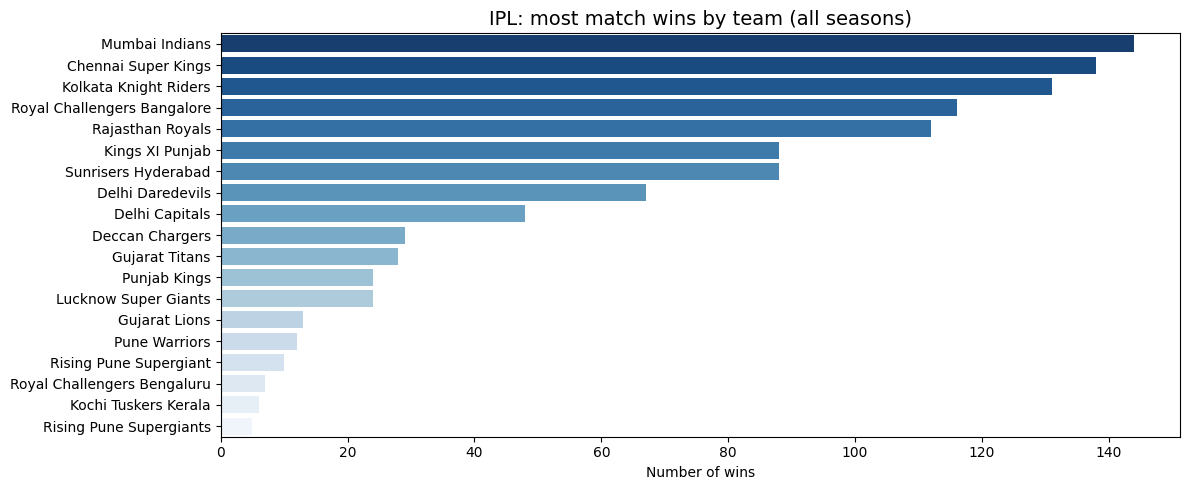

In [45]:
plt.figure(figsize=(12, 5))
sns.barplot(x=wins.values, y=wins.index, palette="Blues_r")
plt.title("IPL: most match wins by team (all seasons)", fontsize=14)
plt.xlabel("Number of wins")
plt.ylabel("")
plt.tight_layout()
plt.savefig("team_wins.png", dpi=150)
plt.show()

In [ ]:
deliveries

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260915,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,5,SS Iyer,AK Markram,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260916,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,6,VR Iyer,AK Markram,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260917,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,Shahbaz Ahmed,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260918,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,Shahbaz Ahmed,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN


In [47]:
top_batsmen = (deliveries.groupby("batter")["batsman_runs"]
               .sum()
               .sort_values(ascending=False)
               .head(10))

C:\Users\savan\AppData\Local\Temp\ipykernel_24476\2467982197.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette="YlOrRd_r")


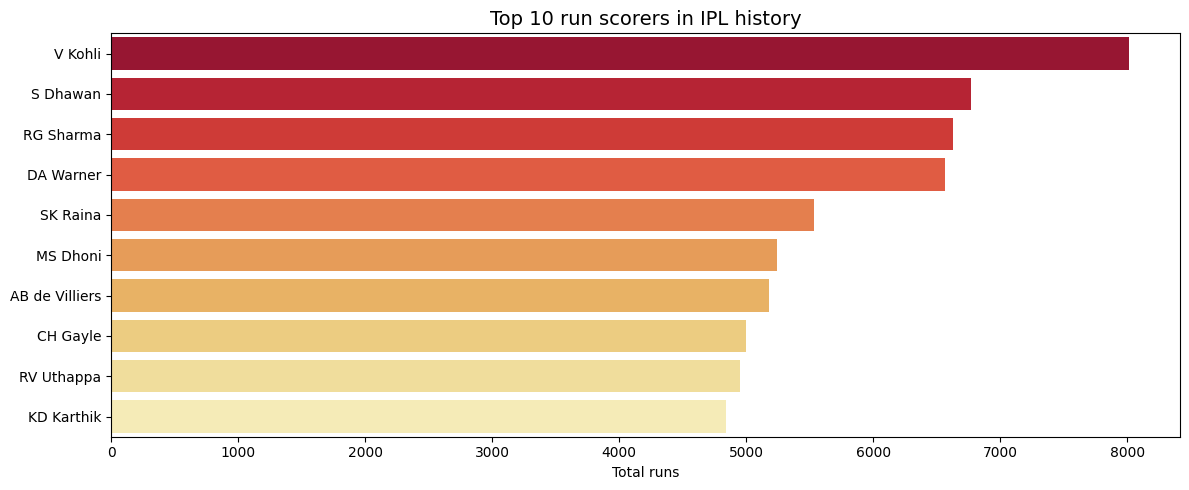

In [48]:
plt.figure(figsize=(12, 5))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette="YlOrRd_r")
plt.title("Top 10 run scorers in IPL history", fontsize=14)
plt.xlabel("Total runs")
plt.ylabel("")
plt.tight_layout()
plt.savefig("top_batsmen.png", dpi=150)
plt.show()

In [49]:
wickets = deliveries[
    (deliveries["dismissal_kind"].notna()) &
    (deliveries["dismissal_kind"] != "run out")
]

top_bowlers = (wickets.groupby("bowler")["player_dismissed"]
               .count()
               .sort_values(ascending=False)
               .head(10))

C:\Users\savan\AppData\Local\Temp\ipykernel_24476\2193148371.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette="Greens_r")


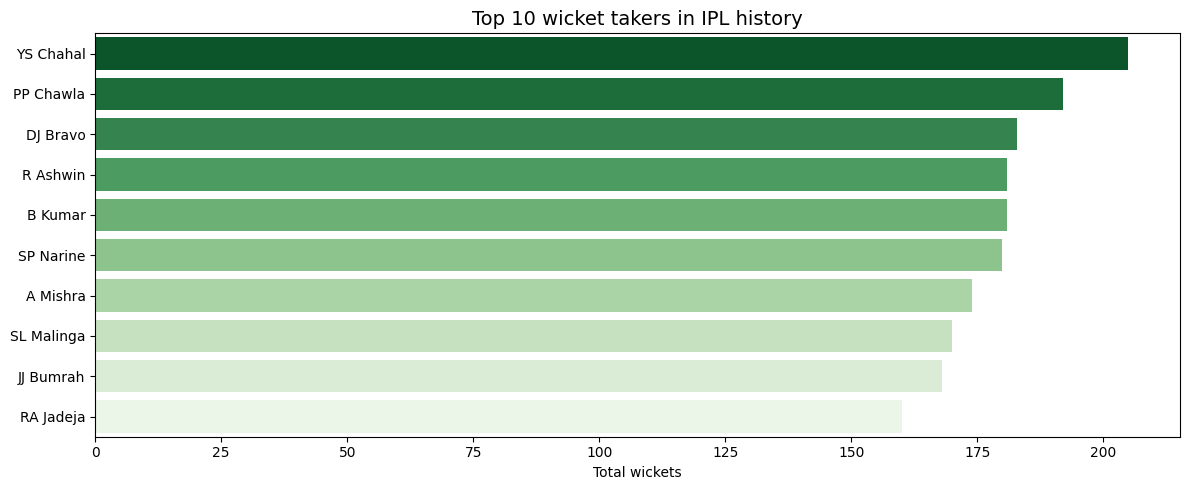

In [50]:
plt.figure(figsize=(12, 5))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette="Greens_r")
plt.title("Top 10 wicket takers in IPL history", fontsize=14)
plt.xlabel("Total wickets")
plt.ylabel("")
plt.tight_layout()
plt.savefig("top_bowlers.png", dpi=150)
plt.show()

In [51]:
matches["toss_match_win"] = matches["toss_winner"] == matches["winner"]

toss_win_pct = matches["toss_match_win"].value_counts(normalize=True) * 100
print(toss_win_pct)

toss_match_win
True     50.593607
False    49.406393
Name: proportion, dtype: float64


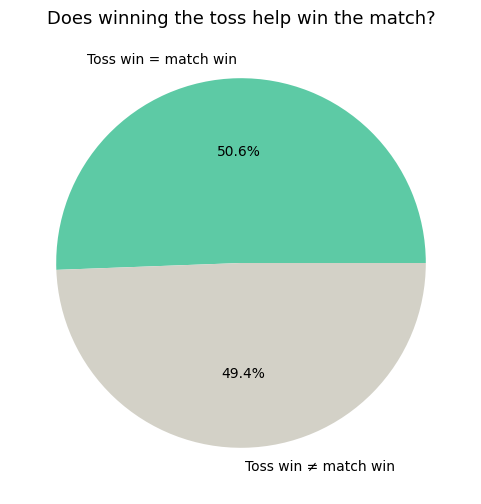

In [52]:
plt.figure(figsize=(6, 6))
plt.pie(toss_win_pct, labels=["Toss win = match win", "Toss win ≠ match win"],
        autopct="%1.1f%%", colors=["#5DCAA5", "#D3D1C7"])
plt.title("Does winning the toss help win the match?", fontsize=13)
plt.savefig("toss_analysis.png", dpi=150)
plt.show()

In [53]:
merged = deliveries.merge(matches[["id", "season"]], 
                          left_on="match_id", right_on="id")

season_runs = merged.groupby("season")["total_runs"].sum()

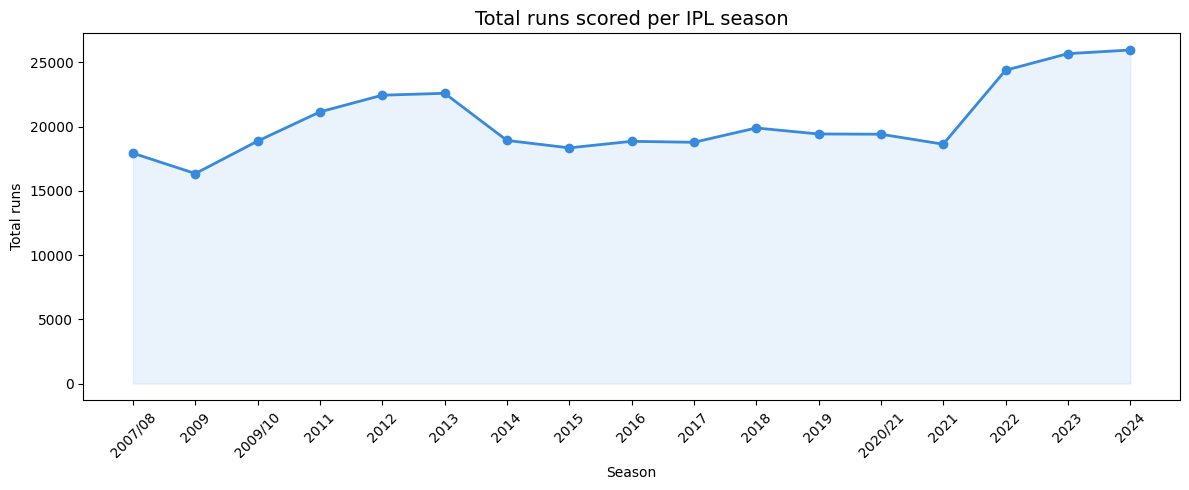

In [54]:
plt.figure(figsize=(12, 5))
plt.plot(season_runs.index, season_runs.values, marker="o", 
         color="#378ADD", linewidth=2, markersize=6)
plt.fill_between(season_runs.index, season_runs.values, alpha=0.1, color="#378ADD")
plt.title("Total runs scored per IPL season", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Total runs")
plt.xticks(season_runs.index, rotation=45)
plt.tight_layout()
plt.savefig("season_runs.png", dpi=150)
plt.show()